# Inequalities in the equation language

`y = 1.5*x ~ N(0, 0.15)` says the residual `r = y - 1.5x` *is* N(0, 0.15) —
a moment match, and the fitted cloud hugs a line. The new form
`y > 1.5*x ~ N(0, 0.15)` says only that `r >= 0`: a **support restriction**,
carried by a per-sample hinge `E[relu(-r)^2]`, with the noise tail setting how
softly the boundary is enforced. Max-entropy then spreads over the *whole*
admissible region instead of concentrating on a curve.

Two demos, both with an exactly-known answer:

1. **Half-plane** — `y > 1.5*x ~ N(0, 0.15)`. Max-ent target: uniform on the
   wedge (checked against rejection sampling from the box).
2. **Band** — `y > 1.5*x` and `y < 1.5*x + 0.8`, sharp. The strip has constant
   width, so the answer is analytic: `x` uniform, residual uniform on
   `[0, 0.8]`, differential entropy `log(0.8)`. No equality constraint can
   express this shape.

In [3]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # tiny problem, CPU is fine
import numpy as np
import matplotlib.pyplot as plt
from calibrated_response.models.variable import ContinuousVariable
from calibrated_response.models.natural_response import parse_natural_syntax as P
from calibrated_response.maxent_sampler.distribution_builder import DistributionBuilder

SLOPE, WIDTH, SOFT = 1.5, 0.8, 0.15
XLO, XHI, YLO, YHI = 0.0, 1.0, -0.6, 2.6

variables = [
    ContinuousVariable(name="x", description="predictor", lower_bound=XLO, upper_bound=XHI),
    ContinuousVariable(name="y", description="response",  lower_bound=YLO, upper_bound=YHI),
]

def fit(exprs, steps=1500, **kw):
    b = DistributionBuilder(variables, [P(e) for e in exprs], n_layers=6, hidden=64, **kw)
    b.build(steps=steps, lr=3e-2, n_samples=2048, seed=0)
    d = b.sample_dict(40000, seed=1)
    return b, d["x"], d["y"]

def box_reject(keep, n=40000, seed=0):
    """Ground truth: uniform on the box, keeping only what satisfies the constraint."""
    rng = np.random.default_rng(seed)
    X, Y = rng.uniform(XLO, XHI, 40 * n), rng.uniform(YLO, YHI, 40 * n)
    m = keep(X, Y)
    return X[m][:n], Y[m][:n]

def report(b):
    for row in b.constraint_report():
        print(f"  {row['estimate']:<26} target={row['target']}  fitted={row['fitted']:.4f}")

In [4]:
# --- 1. half-plane: y > 1.5*x, boundary softened over 0.15 -------------------
b1, x1, y1 = fit(["y > 1.5*x ~ N(0, 0.15)"])
xr1, yr1 = box_reject(lambda X, Y: Y > SLOPE * X)          # uniform-on-wedge truth
r1 = y1 - SLOPE * x1

print(f"fraction satisfying y > 1.5x : {np.mean(r1 > 0):.3f}   (soft edge, so a little <1)")
print(f"rms violation                : {np.sqrt(np.mean(np.minimum(r1, 0)**2)):.4f}   (scale of the softness: {SOFT})")
print(f"E[x]  flow / uniform-wedge   : {x1.mean():.3f} / {xr1.mean():.3f}")
print(f"E[y]  flow / uniform-wedge   : {y1.mean():.3f} / {yr1.mean():.3f}")
print(f"entropy flow / log(area)     : {b1.entropy():.3f} / {np.log(YHI * (XHI - XLO) - 0.5 * SLOPE * XHI**2):.3f}")
report(b1)

fraction satisfying y > 1.5x : 0.918   (soft edge, so a little <1)
rms violation                : 0.0454   (scale of the softness: 0.15)
E[x]  flow / uniform-wedge   : 0.426 / 0.432
E[y]  flow / uniform-wedge   : 1.541 / 1.622
entropy flow / log(area)     : 0.741 / 0.615
  y > 1.5*x ~ N(0, 0.15)     target=0.0  fitted=0.0446


In [5]:
# --- 2. band: two sharp inequalities carve a constant-width strip ------------
# no `~ N(0, s)` tail => the edge is as sharp as a deterministic identity,
# tightened here from the default 3% of the y-span to 1%.
b2, x2, y2 = fit(["y > 1.5*x", "y < 1.5*x + 0.8"], eqn_rel_sd=0.01)
r2 = y2 - SLOPE * x2

print(f"fraction inside the band : {np.mean((r2 > 0) & (r2 < WIDTH)):.3f}   (want ~1)")
print(f"E[x]                     : {x2.mean():.3f}   (want 0.500 - constant-width strip)")
print(f"residual mean / sd       : {r2.mean():.3f} / {r2.std():.3f}   "
      f"(uniform[0, {WIDTH}]: {WIDTH/2:.3f} / {WIDTH/np.sqrt(12):.3f})")
print(f"entropy / log(area)      : {b2.entropy():.3f} / {np.log(WIDTH):.3f}")
report(b2)

fraction inside the band : 0.947   (want ~1)
E[x]                     : 0.500   (want 0.500 - constant-width strip)
residual mean / sd       : 0.409 / 0.239   (uniform[0, 0.8]: 0.400 / 0.231)
entropy / log(area)      : -0.151 / -0.223
  y > 1.5*x                  target=0.0  fitted=0.0041
  y < 1.5*x + 0.8            target=0.0  fitted=0.0076


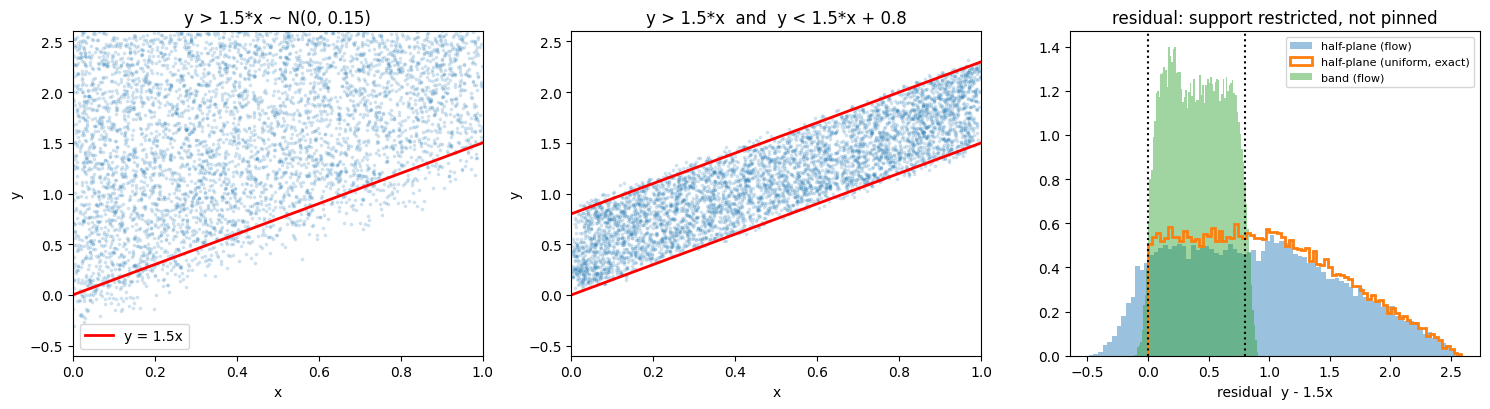

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
xs = np.linspace(XLO, XHI, 100)

ax[0].scatter(x1[:5000], y1[:5000], s=3, alpha=0.15)
ax[0].plot(xs, SLOPE * xs, "r-", lw=2, label="y = 1.5x")
ax[0].set(xlabel="x", ylabel="y", xlim=(XLO, XHI), ylim=(YLO, YHI),
          title="y > 1.5*x ~ N(0, 0.15)")
ax[0].legend()

ax[1].scatter(x2[:5000], y2[:5000], s=3, alpha=0.15)
ax[1].plot(xs, SLOPE * xs, "r-", lw=2)
ax[1].plot(xs, SLOPE * xs + WIDTH, "r-", lw=2)
ax[1].set(xlabel="x", ylabel="y", xlim=(XLO, XHI), ylim=(YLO, YHI),
          title=f"y > 1.5*x  and  y < 1.5*x + {WIDTH}")

ax[2].hist(r1, bins=80, density=True, alpha=0.45, label="half-plane (flow)")
ax[2].hist(yr1 - SLOPE * xr1, bins=80, density=True, histtype="step", lw=2,
           label="half-plane (uniform, exact)")
ax[2].hist(r2, bins=80, density=True, alpha=0.45, label="band (flow)")
ax[2].axvline(0, color="k", ls=":")
ax[2].axvline(WIDTH, color="k", ls=":")
ax[2].set(xlabel="residual  y - 1.5x", title="residual: support restricted, not pinned")
ax[2].legend(fontsize=8)

plt.tight_layout()